# Linear Transformations

A linear transformation is a function $T$ that maps vectors in one vector space $V$ to vectors in another vector space $W$ such that the following two properties hold:

1. $T(\vec{u} + \vec{v}) = T(\vec{u}) + T(\vec{v})$ for all $\vec{u}, \vec{v} \in V$
2. $T(c\vec{u}) = cT(\vec{u})$ for all $\vec{u} \in V$ and all scalars $c$
3. $T(\vec{0}) = \vec{0}$ (where $\vec{0}$ is the zero vector in $V$)

The first two properties are called the **additivity** and **homogeneity** properties, respectively. The third property is a consequence of the first two.

A linear transformation $T$ is completely determined by its action on a basis for $V$. If $\{\vec{e}_1, \vec{e}_2, \ldots, \vec{e}_n\}$ is a basis for $V$, then for any vector $\vec{v} \in V$, we can write $\vec{v}$ as a linear combination of the basis vectors:

$$\vec{v} = \sum_{i=1}^n c_i \vec{e}_i$$

Then, the action of $T$ on $\vec{v}$ is given by:

$$T(\vec{v}) = \sum_{i=1}^n c_i T(\vec{e}_i)$$

In other words, $T$ is completely determined by its action on the basis vectors $\vec{e}_i$.

In [1]:
# import libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

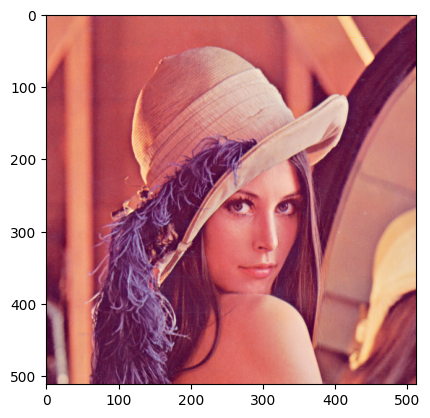

In [2]:
# Load lenna image in the normal color mode (BGR)
img = cv.imread('img/lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# show image on the notebook
plt.imshow(img)
plt.show()

## Scaling

A scaling transformation is a linear transformation that scales each vector in a vector space by a constant factor. For example, a scaling transformation $T$ that scales each vector by a factor of 2 is given by:

$$T(\vec{v}) = c\vec{v}$$

In other words, $T$ scales each vector by a factor of $c$.

[[0.5 0.  0. ]
 [0.  0.5 0. ]]


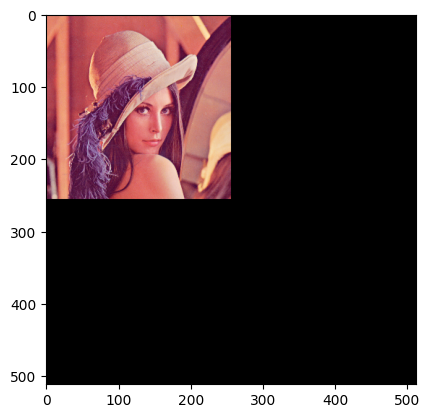

In [3]:
# make a copy of the image
img_copy = img.copy()

# get the image shape
height, width, channels = img_copy.shape

# define the transformation matrix
# A good way to think about the transformation matrix is that you are multiplying each pixel's coordinate by the matrix and the result is the new coordinate of the pixel.

# Scaling
# Scales the image by a factor of 0.5 in both directions
scale: float = 0.5
scale_mat = np.float32([[scale, 0, 0], [0, scale, 0]])
print(scale_mat)

# apply the transformation matrix
scaled_img = cv.warpAffine(img_copy, scale_mat, (width, height))

# show image on the notebook
plt.imshow(scaled_img)
plt.show()

# Rotation

A rotation transformation is a linear transformation that rotates each vector in a vector space by a certain angle. For example, a rotation transformation $T$ that rotates each vector by an angle of $\theta$ is given by:

$$T(\vec{v}) = \begin{bmatrix} \cos \theta & -\sin \theta \\ \sin \theta & \cos \theta \end{bmatrix} \vec{v}$$

In other words, $T$ rotates each vector by an angle of $\theta$.

[[  0.43837115   0.89879405 -86.31428943]
 [ -0.89879405   0.43837115 373.86826227]]


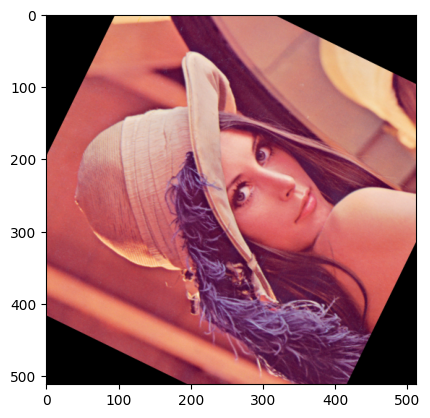

In [4]:
img_copy = img.copy()
# ROTATION
# n_deg = -2
# n_degrees = n_deg * np.pi / 180
n_degrees = 64

# define the transformation matrix
# rot_mat = np.float32([[np.cos(n_degrees), -np.sin(n_degrees), 0], [np.sin(n_degrees), np.cos(n_degrees), 0]])
rot_mat = cv.getRotationMatrix2D((width/2, height/2), n_degrees, 1)  # * use this function to get the rotation matrix
# The .getRotationMatrix2D() function takes the following parameters:
    # - center: the center of rotation
    # - angle: the angle of rotation
    # - scale: an optional scale factor
print(rot_mat)

# apply the transformation matrix
rotated_img = cv.warpAffine(img_copy, rot_mat, (width, height))

# show image on the notebook
plt.imshow(rotated_img)
plt.show()

# 

## Shear

A shear transformation is a linear transformation that shears each vector in a vector space by a certain amount. For example, a shear transformation $T$ that shears each vector by an amount of $c$ is given by:

$$T(\vec{v}) = \begin{bmatrix} 1 & c \\ 0 & 1 \end{bmatrix} \vec{v}$$

In other words, $T$ shears each vector by an amount of $c$.



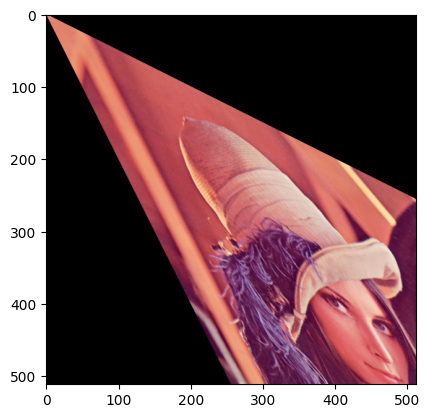

In [23]:
# Shearing
img_copy = img.copy()
# show image on the notebook
# plt.imshow(img_copy)
# plt.show()


# define the transformation matrix
shear_scale = 1.1
shear_scale = 1
# shear_scale = 0.9
shear_mat = np.float32([[shear_scale, 0.5, 0], [0.5, shear_scale, 0]])


# apply the transformation matrix
sheared_img = cv.warpAffine(img_copy, shear_mat, (width, height))

# show image on the notebook
plt.imshow(sheared_img)
plt.show()

# Reflection

A reflection transformation is a linear transformation that reflects each vector in a vector space across a certain line. For example, a reflection transformation $T$ that reflects each vector across the line $y = x$ is given by:

$$T(\vec{v}) = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \vec{v}$$